In [1]:
import pandas as pd

# Looking at first 5 rows (default # of rows for `.head()`) of the first file
df = pd.read_parquet("../data/raw/1-Neris-20110810.binetflow.parquet")
df.head()

,dur,proto,dir,state,stos,dtos,tot_pkts,tot_bytes,src_bytes,label,Family
0,1.026539,tcp,->,S_RA,0.0,0.0,4,276,156,flow=Background-Established-cmpgw-CVUT,20110810.binetflow.csv
1,1.009595,tcp,->,S_RA,0.0,0.0,4,276,156,flow=Background-Established-cmpgw-CVUT,20110810.binetflow.csv
2,3.056586,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv
3,3.111769,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv
4,3.083411,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv


### **Label Understanding**

In [2]:
df['label'].value_counts()

label
flow=Background-UDP-Established                                            815604
flow=To-Background-UDP-CVUT-DNS-Server                                     220506
flow=Background-TCP-Established                                            218569
flow=Background-Established-cmpgw-CVUT                                     136333
flow=Background-TCP-Attempt                                                 60097
                                                                            ...  
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-49                                 1
flow=From-Botnet-V42-TCP-Established-HTTP-Ad-60                                 1
flow=From-Botnet-V42-TCP-Established-HTTP-Adobe-4                               1
flow=From-Botnet-V42-TCP-Established-HTTP-Binary-Download-Custom-Port-5         1
flow=From-Botnet-V42-TCP-HTTP-Not-Encrypted-Down-2                              1
Name: count, Length: 113, dtype: int64

In [3]:
df['label'].unique()

['flow=Background-Established-cmpgw-CVUT', 'flow=Background-TCP-Attempt', 'flow=Background-TCP-Established', 'flow=Background-Attempt-cmpgw-CVUT', 'flow=To-Background-CVUT-Proxy', ..., 'flow=From-Botnet-V42-UDP-Attempt-DNS', 'flow=From-Botnet-V42-TCP-Established-HTTP-Ad-52', 'flow=From-Botnet-V42-TCP-Established-HTTP-Ad-49', 'flow=From-Botnet-V42-TCP-Established-HTTP-Ad-34', 'flow=Background-CS-Host-CVUT']
Length: 113
Categories (113, str): ['flow=Background', 'flow=Background-Attempt-cmpgw-CVUT', 'flow=Background-CS-Host-CVUT', 'flow=Background-Established-cmpgw-CVUT', ..., 'flow=To-Background-MatLab-Server', 'flow=To-Background-Stribrek', 'flow=To-Background-UDP-CVUT-DNS-Server', 'flow=To-Normal-V42-UDP-NTP-server']

I.e. There are 113 categories (raw labels). These are descriptions of network traffic context.

In [4]:
df['label_clean'] = df['label'].str.extract(r'flow=([^-]+)')
df['label_clean'].value_counts()

label_clean
Background    1319801
To             243403
From            57960
Normal              9
Name: count, dtype: int64

In [5]:
df['label_clean'].value_counts(normalize=True)

label_clean
Background    0.814103
To            0.150140
From          0.035752
Normal        0.000006
Name: proportion, dtype: float64

The 2 cells above haven't extracted the classes necessary (something like 'Botnet' and 'Background'). 

The following cells will extract botnet and non-botnet classes (binary classification).

In [6]:
df['is_botnet'] = df['label'].str.contains('Botnet').astype(int)
df['is_botnet'].value_counts()

is_botnet
0    1587187
1      33986
Name: count, dtype: int64

Note `0` are those that don't contain 'Botnet', and `1` are those that do.

In [7]:
df['is_botnet'].value_counts(normalize=True)

is_botnet
0    0.979036
1    0.020964
Name: proportion, dtype: float64

It is clear that the data is severely imbalanced, but this seems realistic (most network traffic would be normal/benign, only a small proportion would be malicious).

### **Feature Understanding**

In [8]:
# Looking at what types of data each label deals with
df.dtypes

dur             float32
proto          category
dir            category
state          category
stos            float32
dtos            float32
tot_pkts          int32
tot_bytes         int64
src_bytes         int64
label          category
Family         category
label_clean      object
is_botnet         int64
dtype: object

In [9]:
df['proto'].value_counts()

proto
udp          1153511
tcp           448832
icmp           13411
rtp             2570
rtcp            2304
arp              443
ipv6-icmp         50
esp               10
ipv6              10
udt               10
ipx/spx            8
pim                7
rarp               4
igmp               2
unas               1
Name: count, dtype: int64

Looking at the categorical classes:

In [10]:
df['dir'].value_counts()

dir
<->    1109168
 ->     502286
<?>       6139
<-        1702
 ?>       1426
who        447
<?           5
Name: count, dtype: int64

In [11]:
df['state'].value_counts()

state
CON          1108492
FSPA_FSPA     215447
S_RA           52222
INT            49410
SRPA_FSPA      35374
              ...   
_FA                1
_FRPA              1
_FSRPA             1
_R                 1
_RA                1
Name: count, Length: 230, dtype: int64

Looking at the numerical classes:

In [12]:
df[['dur', 'tot_pkts', 'tot_bytes', 'src_bytes']].describe()

,dur,tot_pkts,tot_bytes,src_bytes
count,1.621173e+06,1.621173e+06,1.621173e+06,1.621173e+06
mean,7.506620e+02,4.293056e+01,3.345778e+04,7.174597e+03
std,1.218352e+03,4.124564e+03,4.239958e+06,2.453215e+06
min,0.000000e+00,1.000000e+00,6.000000e+01,0.000000e+00
25%,4.504000e-03,2.000000e+00,2.680000e+02,8.200000e+01
50%,2.021557e+00,4.000000e+00,5.410000e+02,1.860000e+02
75%,1.427422e+03,1.000000e+01,1.520000e+03,7.840000e+02
max,3.600031e+03,2.686731e+06,2.689640e+09,2.635366e+09


In [13]:
df['stos'].value_counts()

stos
0.0      1613162
2.0         1323
3.0          914
1.0          620
192.0          9
Name: count, dtype: int64

In [14]:
df[['stos', 'dtos']].describe()

,stos,dtos
count,1.616028e+06,1.529939e+06
mean,4.787046e-03,7.614683e-04
std,4.626329e-01,4.368807e-02
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00
max,1.920000e+02,3.000000e+00


In [15]:
df['dtos'].value_counts()

dtos
0.0    1529441
2.0        245
3.0        211
1.0         42
Name: count, dtype: int64

array([[<Axes: title={'center': 'dur'}>,
        <Axes: title={'center': 'tot_pkts'}>],
       [<Axes: title={'center': 'tot_bytes'}>,
        <Axes: title={'center': 'src_bytes'}>]], dtype=object)

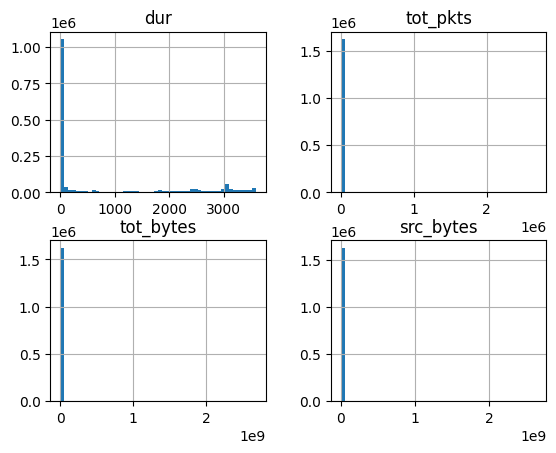

In [16]:
df[['dur', 'tot_pkts', 'tot_bytes', 'src_bytes']].hist(bins=50)

Few things to note from the results above:

1. Numerical features all exhibit a heavy-right skew.
    - Most flows are very small and very short.
    - Very few are extremeley large and dominate the scale.

2. Numerical features `stos` and `dtos` are worth excluding.
    - Heavy skew towards the value 0 for both.
    - Very small variance $10^{-1}$ and $10^{-2}$, compared to the others which are $10^3$ and $10^6$.

3. Categorical features `proto` and `dir` are worth keeping for the baseline features, while `state` is not.
    - `proto` has a moderate number of of unique values (dominated by first 2). 
    - `dir` has a smaller number of unique values (again dominated by first 2).
        - `proto` and `dir` can be one-shot encoded.
    - `state` has 230 unique values, which leaves a long tail of rare categories.

## **First Model**

The goal here is to develop a **clean, interpretable baseline** to then build upon.

**Data:**
```
X = [dur, tot_pkts, tot_bytes, src_bytes, proto, dir]
y = is_botnet
```
(Note, currently learning behaviour from ONE environment: just one .parquet file.)

- Using one-shot encoding on `proto` and `dir`.
- Using a random forest classifier.

### Preparing Data

In [17]:
# Checking the columns in the dataframe at the moment to know what to remove for input X
df.head()

,dur,proto,dir,state,stos,dtos,tot_pkts,tot_bytes,src_bytes,label,Family,label_clean,is_botnet
0,1.026539,tcp,->,S_RA,0.0,0.0,4,276,156,flow=Background-Established-cmpgw-CVUT,20110810.binetflow.csv,Background,0
1,1.009595,tcp,->,S_RA,0.0,0.0,4,276,156,flow=Background-Established-cmpgw-CVUT,20110810.binetflow.csv,Background,0
2,3.056586,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv,Background,0
3,3.111769,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv,Background,0
4,3.083411,tcp,->,SR_A,0.0,0.0,3,182,122,flow=Background-TCP-Attempt,20110810.binetflow.csv,Background,0


In [ ]:
# Define target
y = df['is_botnet']

# Define features (i.e. everything besides the target)
X = df.drop(columns=['is_botnet'])

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=['proto', 'dir'], drop_first=True)

X = X_encoded.to_numpy()
y = y.to_numpy()

The `drop_first=True` parameter in `pd.get_dummies()` drops the first category of each categorical variable when creating dummy variables. 

This is to reduce dimensionality and redundancy simultaneously (without losing any information). For example, if a variable has 3 categories 'red', 'green' and 'blue'. If 'green' and 'blue' are both False, then 'red' must be True. Therefore, 'red' (or one of the other 2) could be removed. 

In [ ]:
# Note this had 26 columns when `drop_first=True` was not in
X_encoded.head()

,dur,tot_pkts,tot_bytes,src_bytes,proto_esp,proto_icmp,proto_igmp,proto_ipv6,proto_ipv6-icmp,proto_ipx/spx,...,proto_tcp,proto_udp,proto_udt,proto_unas,dir_ ?>,dir_ <-,dir_ <->,dir_ <?,dir_ <?>,dir_ who
0,1.026539,4,276,156,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,1.009595,4,276,156,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,3.056586,3,182,122,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,3.111769,3,182,122,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,3.083411,3,182,122,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [40]:
X_encoded.shape

(1621173, 24)

### Applying Random Forest Classifier

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report


In [49]:
# Creating train/test split for data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)   

# Instantiating RF classifier and training it on the training data
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
# Evaluating the model on the test set
y_pred = rf_classifier.predict(X_test)   

# Calculating evaluation metrics
accuracy = rf_classifier.score(X_test, y_test)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.9911
Precision: 0.8221
Recall: 0.7355
Confusion Matrix:
[[316356   1082]
 [  1798   4999]]


### Summary

This notebook makes use of the CTU-13 dataset, a botnet detection dataset containing 13 labelled scenarios, one of which was used here to train a simple Random Forest classifier. The .parquet files contain network flow data.

The dataset had the following features: `dur`,`proto`,`dir`,`state`,`stos`,`dtos`,`tot_pkts`,`tot_bytes`,`src_bytes`,`label`,`Family`.

#### Binary Classification
First, in order to make this a binary classification problem (i.e. whether the network data was botnet data or not), an `is_botnet` binary mask was created from `label` (where `0` was for labels without 'Botnet' present, and `1` for those with 'Botnet' present). This would be used as the supervised classifier true label $y$. Doing this allowed me to see that 98% of the flow data in this scenario was bening (i.e. only 2% botnet), which is a fairly realistic proportion (malicious network flow would generally make up a small minority of network traffic).

#### Feature Selection
Next, the features were explored (that is everything besides `is_botnet`). The numerical features were `dur`, `stos`,`dtos`, `tot_pkts`,`tot_bytes`,`src_bytes`. Of the 6, `stos` and `dtos` were excluded as they exhibited very low variance and were effectively constant across the dataset, indicating limited predictive value.

The categorical classes were `proto`,`dir`,`state`. Of the 3, `state` was excluded as it had >200 unique values (whereas `proto` and `dir` had a notably smaller number - the number of their unique values combined was an order of magnitude less than the number for `state`). This decision was relevant because the categorical classes were to be one-hot encoded (would create >200 new features if `state` was included).

#### Model Development 
Finally, the dataframe that held the data (as well as some additional features that had been created along the way) was stripped of useless labels, leaving only the relevant features and label to be used (`dur`, `tot_pkts`,`tot_bytes`,`src_bytes`,`proto`,`dir` for $X$ and `is_botnet` for $y$). Categorical features were one-hot encoded for the final $X$ array.

A data was then split 80/20 into train/test datasets. A fixed seed was used (`random_state=42`) for consistency, and `stratify=y` ensured that the ttrain/test data had a similar proportion of 0s and 1s for the `is_botnet` label. The RF model was trained on the train set, and tested on the test set (comparing model predictions for the test input to the true labels). 

#### Model Performance
Model performance was evbauated using accuracy, precision, recall and a confusion matrix. 

- The accuracy was high (99%). This tells use the number of true predictions made.
    $$ \frac{TP + TN}{\text{total}}$$
- The precision was reasonably high (82%). This is a description of the model's strength in prediction. It tells us that **of all flows predicted as botnet, 82% were actually botnet.**
    $$ \frac{TP}{TP+ FP} $$
- The recall was moderately high (74%). This is a description of the model's ability to discern botnet flows from non-botnet flows. It tells us that the model detects 74% of actual botnet traffic.
    $$ \frac{TP}{TP + FN} $$

- The confusion matrix has values for (going left to right, top to bottom):
    - True Negatives (TN): 316,356
    - False Positives (FP): 1,082
    - False Negatives (FN): 1,798
    - True Positives (TP): 4,999

- As an extra point to note, the false positive rate (FPR) is very low (0.3%). This tells us the model is correct the huge majority of the time when it predicts a flow as benign.
$$ \frac{FP}{FP + TN} $$